# Setup

In [85]:
%matplotlib inline

import os, sys, pickle, warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.ndimage import uniform_filter1d

import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")

import src.utils as utils

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

def set_font_size(font_size=12):
    plt.rcParams.update({
        'font.size': font_size,
        'axes.titlesize': font_size+1,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size-1,
        'ytick.labelsize': font_size-1,
        'legend.fontsize': font_size,
        'figure.titlesize': font_size+2,
    })

# Load data

In [86]:
# path to the pickle file produced by biornn_results_dynamics_trajectory.py
model_params_name = 'model_params_202603bp'
username = os.getenv('USER')
if sys.platform == 'darwin':
    if username == 'ahmad':
        datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
        modeldir = os.path.join('/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model', model_params_name)
        # modeldir = os.path.join('/Volumes/Sabrent_2TB/rutgers/neuro_rnn/data', model_params_name)
        # modeldir = '/Users/ahmad/Downloads'
elif sys.platform == 'linux':
    if username == 'ab2792':
        datadir = '/home/ab2792/software/snaplab_github/neuro_rnn/data'
        modeldir = '/home/ab2792/data/neuro_rnn/results/pytorch/model'
    elif username == 'lindenmp':
        datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
        modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/model_cpu'

results_file = os.path.join(modeldir, f'training_trajectory_{model_params_name}.pkl')
with open(results_file, 'rb') as f:
    data = pickle.load(f)

save_figs = True #False
outdir = modeldir

# set to an integer to limit plots to epochs <= this value; None = plot all
max_plot_epoch = 30000 #None

# set to a list of CSV row numbers to include (matches the script's --rows); None = plot all
# (run the "Unpack results" cell to see available rows)
plot_models = [10, 11, 12, 13, 16] #None

print(f'Loaded: {results_file}')
print(f'Models: {len(data["results"])}')
print(f'Args: {data["args"]}')

Loaded: /Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model/model_params_202603bp/training_trajectory_model_params_202603bp.pkl
Models: 5
Args: {'model_params': 'model_params_202603bp', 'rows': [10, 11, 12, 13, 16], 'n_epochs': -1, 'n_trials': 100, 'n_fmri_subj': 100, 'n_pc': 5, 'n_jobs': 25, 'max_epoch': 30000, 'max_runs': 100, 'outdir': '/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model', 'skip_fmri': False}


# Unpack results

In [87]:
model_params = data['model_params']
fmri_baselines = data['fmri_intersubj_baselines']
results = data['results']
n_models = len(results)

# derive task/kernel structure
task_names = list(model_params.task_no_modifier.unique())
n_tasks = len(task_names)
kernel_labels = list(model_params.kernel_label.unique())
n_kernels = len(kernel_labels)

# detect available node subsets
subset_names = ['all']
for res in results:
    if res is None:
        continue
    ns = res.get('node_subsets')
    if ns is not None and len(ns) > 1:
        subset_names = list(ns.keys())
        break

# optionally limit plotted epochs
if max_plot_epoch is not None:
    for res in results:
        if res is None:
            continue
        res['sampled_epochs'] = [ep for ep in res['sampled_epochs'] if ep <= max_plot_epoch]
    print(f'Limiting plots to epochs <= {max_plot_epoch}')

# map results-array indices back to original CSV row numbers
csv_rows = data['args'].get('rows') or list(range(n_models))

# optionally select which models to plot (by CSV row number — same as --rows in the script)
print('Available models:')
for i in range(n_models):
    label = model_params.iloc[i].kernel_label if results[i] is not None else '(no data)'
    task = model_params.iloc[i].task_no_modifier if results[i] is not None else ''
    print(f'  [row {csv_rows[i]}] {task} — {label}')
if plot_models is not None:
    for i in range(n_models):
        if csv_rows[i] not in plot_models:
            results[i] = None
    print(f'Plotting CSV rows: {plot_models}')

# recompute active tasks after filtering so subplot grids fit
active_tasks = []
for i in range(n_models):
    if results[i] is not None:
        t = model_params.iloc[i].task_no_modifier
        if t not in active_tasks:
            active_tasks.append(t)
task_remap = {t: idx for idx, t in enumerate(active_tasks)}
for i in range(n_models):
    if results[i] is not None:
        model_params.at[model_params.index[i], 'task_index'] = task_remap[model_params.iloc[i].task_no_modifier]
task_names = active_tasks
n_tasks = len(task_names)

# color palette (indexed by original kernel_index so colors stay consistent)
if n_kernels <= 3:
    color_palette = utils.get_my_colors(cat_trio=True, as_list=True)
else:
    color_palette = utils.get_my_colors(cat_trio=False, as_list=True)
color_palette = color_palette[:n_kernels]

print(f'Tasks: {task_names}')
print(f'Kernels: {kernel_labels}')
print(f'Node subsets: {subset_names}')
if fmri_baselines['task'] is not None:
    print(f'fMRI baselines — task: {fmri_baselines["task"]:.4f}, rest: {fmri_baselines["rest"]:.4f}')

Limiting plots to epochs <= 30000
Available models:
  [row 10] DelayMatchSampleDistractor1D-v0 — Unmasked Reg. 
  [row 11] DelayMatchSampleDistractor1D-v0 — Masked Reg. 
  [row 12] DelayMatchSampleDistractor1D-v0 — Masked S-F
  [row 13] DelayMatchSampleDistractor1D-v0 — Masked Eucl.
  [row 16] DelayMatchSampleDistractor1D-v0 — Masked SC
Plotting CSV rows: [10, 11, 12, 13, 16]
Tasks: ['DelayMatchSampleDistractor1D-v0']
Kernels: ['Unmasked Reg. ', 'Masked Reg. ', 'Masked S-F', 'Masked Eucl.', 'Masked SC']
Node subsets: ['all', 'no_input', 'no_output', 'no_bystander']
fMRI baselines — task: 0.2733, rest: 0.2690


# Accuracy over training

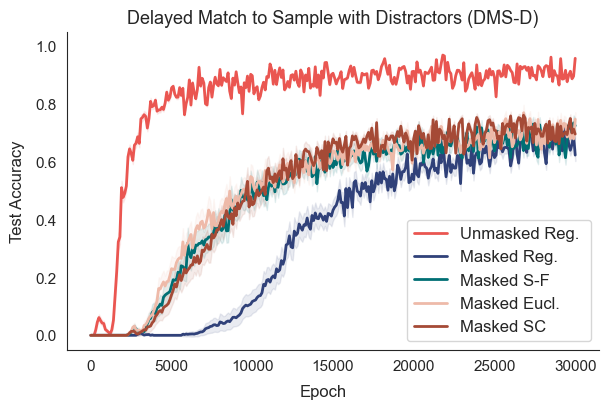

In [88]:
size_scale = 2.0
font_size = int(6 * size_scale)
set_font_size(font_size)
n_fig_columns = min(3, n_tasks)
n_fig_rows = int(np.ceil(n_tasks / n_fig_columns))
fig_size_w = 3 * n_fig_columns * size_scale
fig_size_h = 2 * n_fig_rows * size_scale

fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                       squeeze=True, sharex=True, sharey=True)

for model_idx in range(n_models):
    res = results[model_idx]
    if res is None:
        continue

    this = model_params.iloc[model_idx]
    task_index = this.task_index
    kernel_index = this.kernel_index
    ax = fig.axes[task_index]

    epochs = np.array(res['sampled_epochs'])
    n_runs = res['n_runs']
    acc = np.zeros((n_runs, len(epochs)))

    for ri, run in enumerate(res['runs']):
        for ei, ep in enumerate(epochs):
            acc[ri, ei] = run['epochs'][ep]['accuracy']

    acc_mean = acc.mean(axis=0)
    acc_se = acc.std(axis=0) / np.sqrt(n_runs)

    ax.plot(epochs, acc_mean, color=color_palette[kernel_index],
            label=this.kernel_label, linewidth=2)
    ax.fill_between(epochs, acc_mean - 1.96 * acc_se, acc_mean + 1.96 * acc_se,
                     color=color_palette[kernel_index], alpha=0.1)
    ax.set_title(this.task_label)

fig.axes[0].set_ylim((-0.05, 1.05))
# legend on first subplot only, deduplicated
handles, labels = fig.axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.axes[0].legend(by_label.values(), by_label.keys(), loc='lower right')

fig.text(0.51, 0.0, 'Epoch', ha='center', va='center')
fig.text(0.0, 0.5, 'Test Accuracy', ha='center', va='center', rotation='vertical')
sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
fig.tight_layout()

if save_figs:
    fig.savefig(os.path.join(outdir, 'trajectory_accuracy.svg'),
                dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

# Weight-kernel similarity over training

# Loss components over training

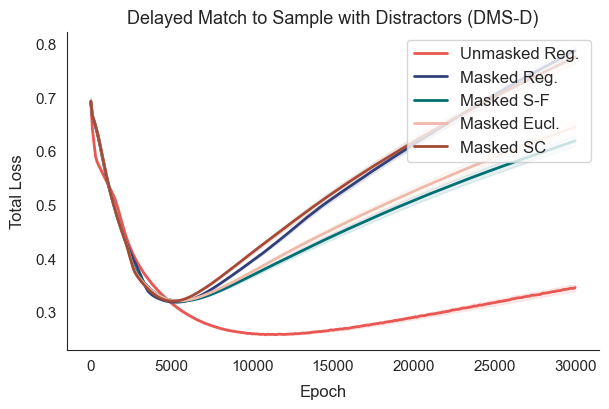

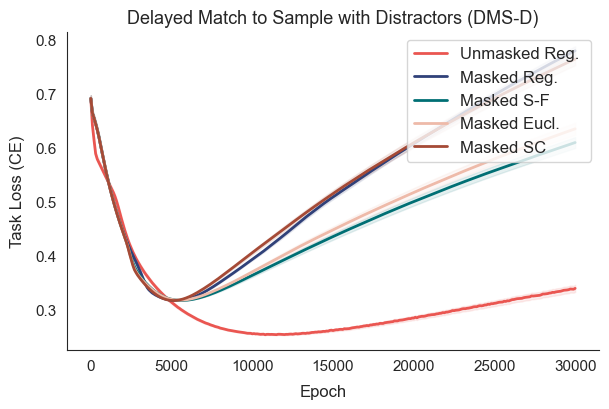

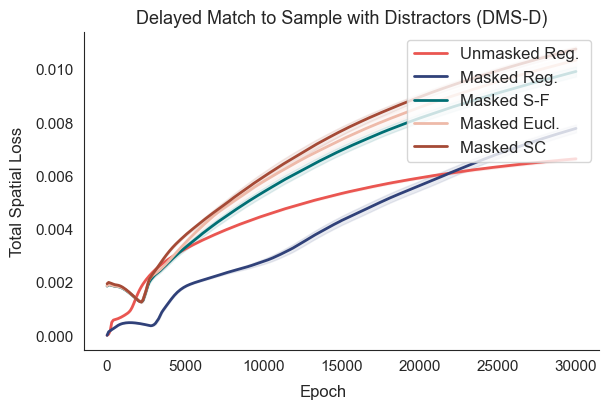

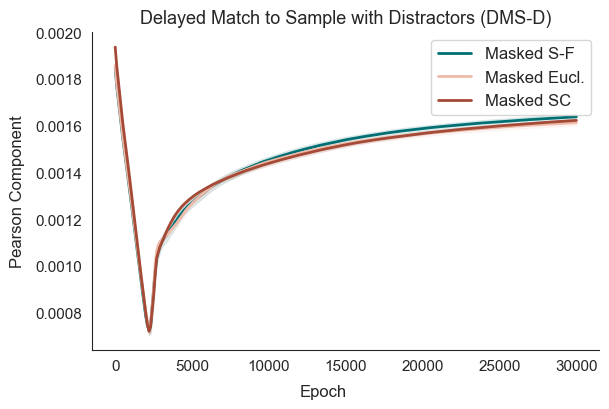

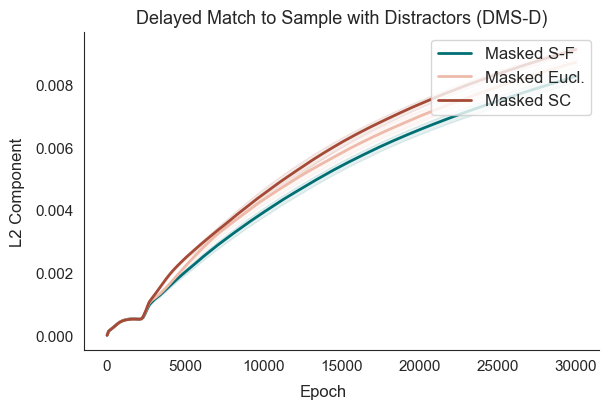

In [89]:
loss_metrics = [
    {'key': 'total_loss',         'ylabel': 'Total Loss',           'file_suff': 'total_loss'},
    {'key': 'task_loss',          'ylabel': 'Task Loss (CE)',       'file_suff': 'task_loss'},
    {'key': 'total_spatial_loss', 'ylabel': 'Total Spatial Loss',   'file_suff': 'spatial_loss'},
    {'key': 'pearson_component',  'ylabel': 'Pearson Component',    'file_suff': 'pearson_component'},
    {'key': 'l2_component',       'ylabel': 'L2 Component',         'file_suff': 'l2_component'},
]

for lm in loss_metrics:
    size_scale = 2.0
    font_size = int(6 * size_scale)
    set_font_size(font_size)
    fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                           squeeze=True, sharex=True, sharey=True)

    any_plotted = False

    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue

        this = model_params.iloc[model_idx]
        task_index = this.task_index
        kernel_index = this.kernel_index
        ax = fig.axes[task_index]

        epochs = np.array(res['sampled_epochs'])
        n_runs = res['n_runs']
        vals = np.full((n_runs, len(epochs)), np.nan)

        for ri, run in enumerate(res['runs']):
            for ei, ep in enumerate(epochs):
                losses = run['epochs'][ep].get('losses')
                if losses is not None:
                    v = losses.get(lm['key'])
                    if v is not None:
                        vals[ri, ei] = v

        if np.all(np.isnan(vals)):
            continue

        any_plotted = True
        vals_mean = np.nanmean(vals, axis=0)
        vals_se = np.nanstd(vals, axis=0) / np.sqrt(n_runs)

        ax.plot(epochs, vals_mean, color=color_palette[kernel_index],
                label=this.kernel_label, linewidth=2)
        ax.fill_between(epochs, vals_mean - 1.96 * vals_se, vals_mean + 1.96 * vals_se,
                         color=color_palette[kernel_index], alpha=0.1)
        ax.set_title(this.task_label)

    if not any_plotted:
        plt.close(fig)
        continue

    handles, labels = fig.axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.axes[0].legend(by_label.values(), by_label.keys(), loc='upper right')

    fig.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    fig.text(0.0, 0.5, lm['ylabel'], ha='center', va='center', rotation='vertical')
    sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    fig.tight_layout()

    if save_figs:
        fig.savefig(os.path.join(outdir, f'trajectory_{lm["file_suff"]}.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()

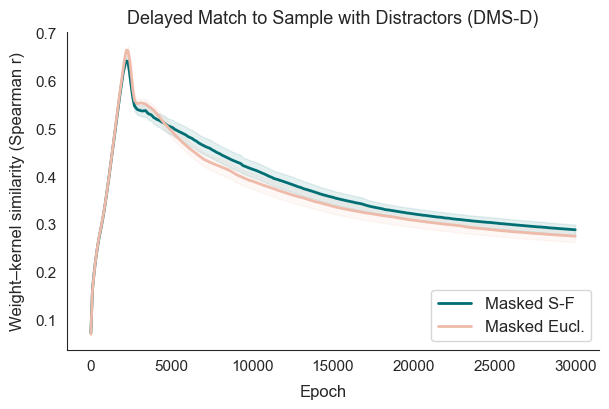

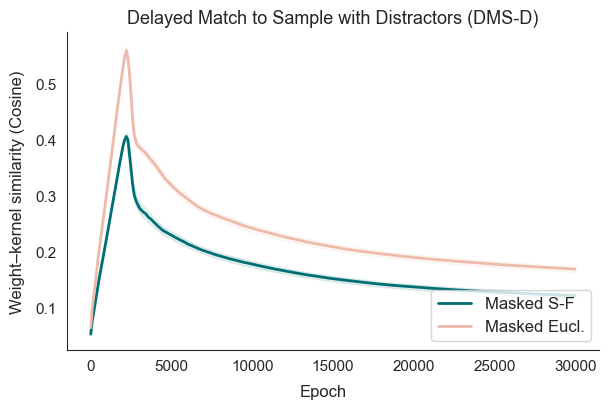

In [90]:
similarity_metrics = {
    'spearman': 'Weight–kernel similarity (Spearman r)',
    'cosine': 'Weight–kernel similarity (Cosine)',
}

for metric_key, metric_label in similarity_metrics.items():

    size_scale = 2.0
    font_size = int(6 * size_scale)
    set_font_size(font_size)
    fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                           squeeze=True, sharex=True, sharey=True)

    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue

        this = model_params.iloc[model_idx]
        task_index = this.task_index
        kernel_index = this.kernel_index
        ax = fig.axes[task_index]

        # skip models without spatial kernel
        if res['runs'][0]['epochs'][res['sampled_epochs'][0]]['weight_kernel_similarity'] is None:
            continue

        epochs = np.array(res['sampled_epochs'])
        n_runs = res['n_runs']
        vals = np.zeros((n_runs, len(epochs)))

        for ri, run in enumerate(res['runs']):
            for ei, ep in enumerate(epochs):
                vals[ri, ei] = run['epochs'][ep]['weight_kernel_similarity'][metric_key]

        vals_mean = vals.mean(axis=0)
        vals_se = vals.std(axis=0) / np.sqrt(n_runs)

        ax.plot(epochs, vals_mean, color=color_palette[kernel_index],
                label=this.kernel_label, linewidth=2)
        ax.fill_between(epochs, vals_mean - 1.96 * vals_se, vals_mean + 1.96 * vals_se,
                         color=color_palette[kernel_index], alpha=0.1)
        ax.set_title(this.task_label)

    handles, labels = fig.axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.axes[0].legend(by_label.values(), by_label.keys(), loc='lower right')

    fig.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    fig.text(0.0, 0.5, metric_label, ha='center', va='center', rotation='vertical')
    sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    fig.tight_layout()

    if save_figs:
        fig.savefig(os.path.join(outdir, f'trajectory_wk_{metric_key}.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()

# fMRI variance explained over training

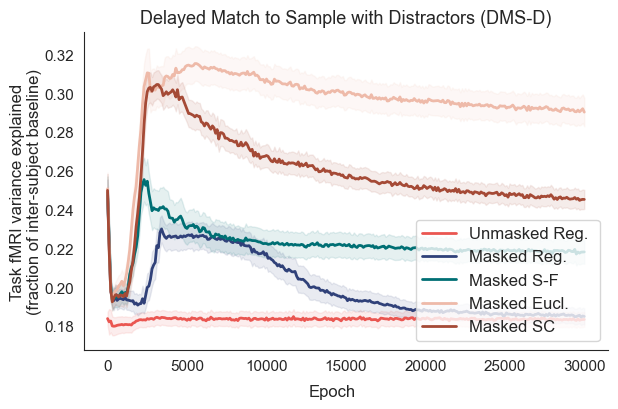

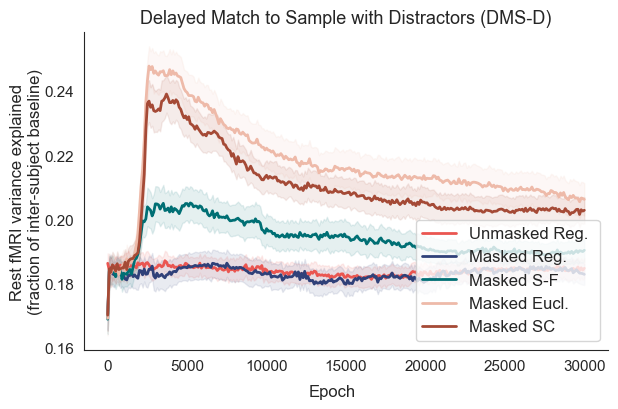

In [91]:
fmri_ve_metrics = [
    {
        'key': 'fmri_task_ve',
        'baseline': fmri_baselines['task'],
        'ylabel': 'Task fMRI variance explained\n(fraction of inter-subject baseline)',
        'file_suff': 'fmri_task_ve',
    },
    {
        'key': 'fmri_rest_ve',
        'baseline': fmri_baselines['rest'],
        'ylabel': 'Rest fMRI variance explained\n(fraction of inter-subject baseline)',
        'file_suff': 'fmri_rest_ve',
    },
]

for vm in fmri_ve_metrics:
    if vm['baseline'] is None:
        print(f'Skipping {vm["key"]} (no fMRI data)')
        continue

    size_scale = 2.0
    font_size = int(6 * size_scale)
    set_font_size(font_size)
    fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                           squeeze=True, sharex=True, sharey=True)

    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue

        this = model_params.iloc[model_idx]
        task_index = this.task_index
        kernel_index = this.kernel_index
        ax = fig.axes[task_index]

        epochs = np.array(res['sampled_epochs'])
        n_runs = res['n_runs']
        vals = np.zeros((n_runs, len(epochs)))

        for ri, run in enumerate(res['runs']):
            for ei, ep in enumerate(epochs):
                ve_arr = run['epochs'][ep][vm['key']]
                if ve_arr is None:
                    vals[ri, ei] = np.nan
                else:
                    # sum across PCs, mean across subjects, normalize by baseline
                    vals[ri, ei] = ve_arr.sum(axis=0).mean() / vm['baseline']

        vals_mean = np.nanmean(vals, axis=0)
        vals_se = np.nanstd(vals, axis=0) / np.sqrt(n_runs)

        ax.plot(epochs, vals_mean, color=color_palette[kernel_index],
                label=this.kernel_label, linewidth=2)
        ax.fill_between(epochs, vals_mean - 1.96 * vals_se, vals_mean + 1.96 * vals_se,
                         color=color_palette[kernel_index], alpha=0.1)
        ax.set_title(this.task_label)

    handles, labels = fig.axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.axes[0].legend(by_label.values(), by_label.keys(), loc='lower right')

    fig.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    fig.text(0.0, 0.5, vm['ylabel'], ha='center', va='center', rotation='vertical')
    sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    fig.tight_layout()

    if save_figs:
        fig.savefig(os.path.join(outdir, f'trajectory_{vm["file_suff"]}.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()

# fMRI variance explained by node subset

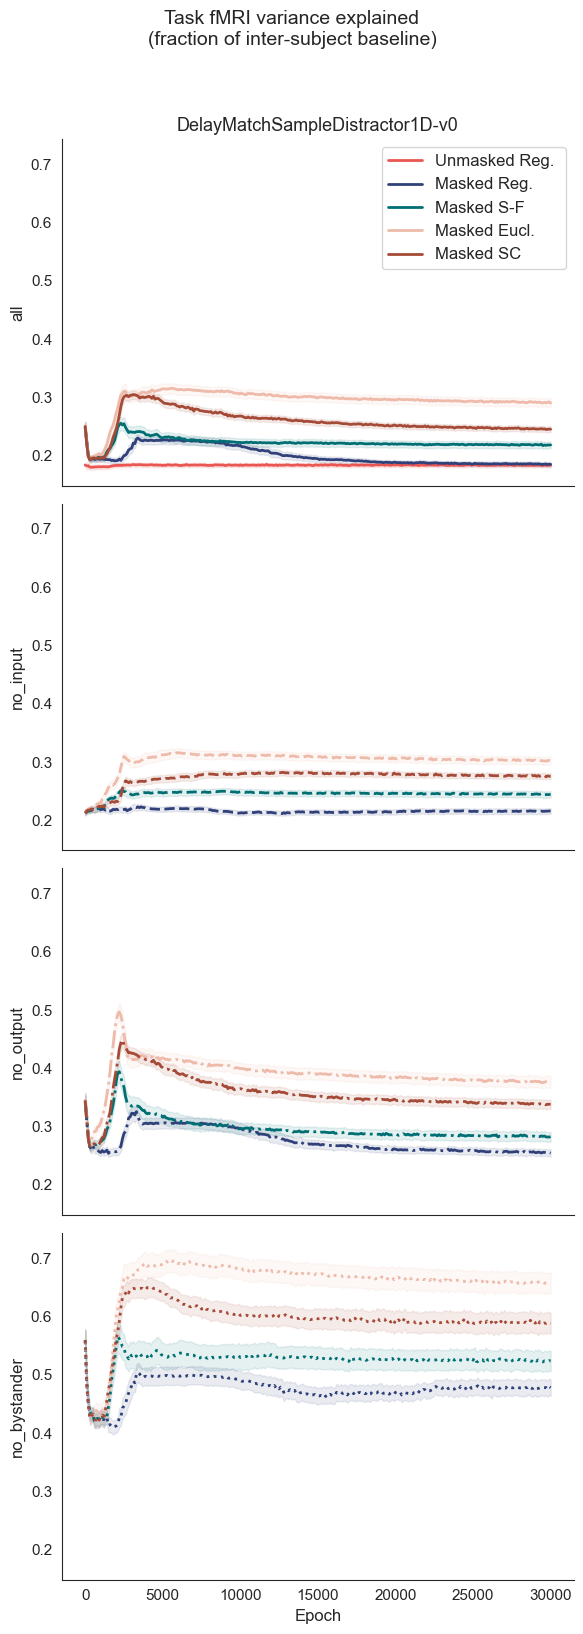

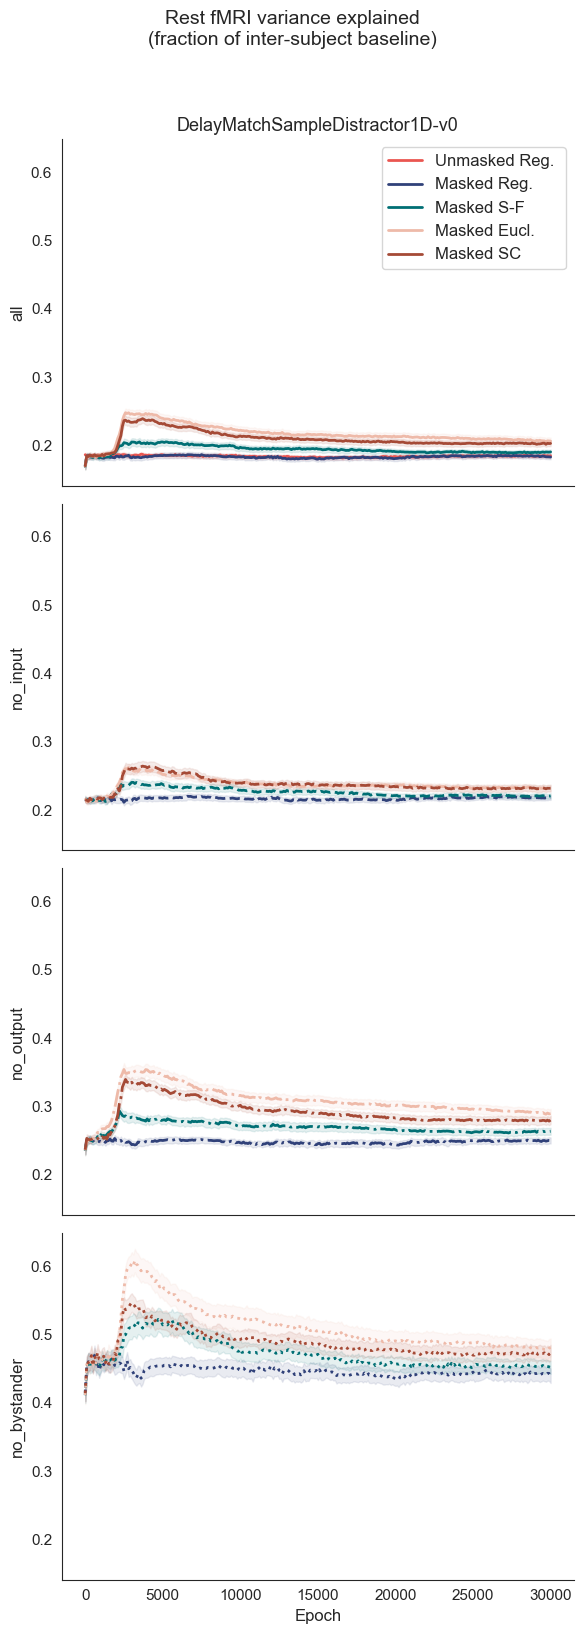

In [92]:
# fMRI VE over training, broken down by node subset
# Rows = node subsets, columns = tasks, colors = kernel types
# Uses node_subsets data when available, falls back to top-level keys for 'all'

if len(subset_names) <= 1:
    print('Only "all" subset available — skipping node subset comparison.')
else:
    subset_linestyles = {
        'all': '-',
        'no_input': '--',
        'no_output': '-.',
        'no_bystander': ':',
    }

    for vm in fmri_ve_metrics:
        if vm['baseline'] is None:
            print(f'Skipping {vm["key"]} (no fMRI data)')
            continue

        n_subset_rows = len(subset_names)
        size_scale = 2.0
        font_size = int(6 * size_scale)
        set_font_size(font_size)
        fig, axes = plt.subplots(
            n_subset_rows, n_fig_columns,
            figsize=(3 * n_fig_columns * size_scale, 2 * n_subset_rows * size_scale),
            squeeze=False, sharex=True, sharey=True)

        for model_idx in range(n_models):
            res = results[model_idx]
            if res is None:
                continue

            this = model_params.iloc[model_idx]
            task_index = this.task_index
            kernel_index = this.kernel_index

            epochs = np.array(res['sampled_epochs'])
            n_runs = res['n_runs']

            for si, sname in enumerate(subset_names):
                ax = axes[si, task_index]
                vals = np.full((n_runs, len(epochs)), np.nan)

                for ri, run in enumerate(res['runs']):
                    for ei, ep in enumerate(epochs):
                        ep_data = run['epochs'][ep]
                        # try node_subsets dict first, fall back to top-level
                        ns = ep_data.get('node_subsets')
                        if ns is not None and sname in ns:
                            ve_arr = ns[sname].get(vm['key'])
                        elif sname == 'all':
                            ve_arr = ep_data.get(vm['key'])
                        else:
                            ve_arr = None
                        if ve_arr is not None:
                            vals[ri, ei] = ve_arr.sum(axis=0).mean() / vm['baseline']

                if np.all(np.isnan(vals)):
                    continue

                vals_mean = np.nanmean(vals, axis=0)
                vals_se = np.nanstd(vals, axis=0) / np.sqrt(n_runs)

                ls = subset_linestyles.get(sname, '-')
                ax.plot(epochs, vals_mean, color=color_palette[kernel_index],
                        linestyle=ls, label=this.kernel_label, linewidth=2)
                ax.fill_between(epochs, vals_mean - 1.96 * vals_se,
                                vals_mean + 1.96 * vals_se,
                                color=color_palette[kernel_index], alpha=0.1)

        # labels and formatting
        for si, sname in enumerate(subset_names):
            axes[si, 0].set_ylabel(sname)
            for col in range(n_fig_columns):
                if si == 0 and col < n_tasks:
                    axes[si, col].set_title(task_names[col])

        for col in range(n_fig_columns):
            axes[-1, col].set_xlabel('Epoch')

        # legend on first subplot
        handles, labels = axes[0, 0].get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        axes[0, 0].legend(by_label.values(), by_label.keys(), loc='upper right')

        fig.suptitle(vm['ylabel'], y=1.02)
        sns.despine(fig=fig, offset=0, trim=False,
                    left=False, right=True, top=True, bottom=False)
        fig.tight_layout()

        if save_figs:
            fig.savefig(os.path.join(outdir, f'trajectory_{vm["file_suff"]}_by_subset.svg'),
                        dpi=300, bbox_inches='tight', pad_inches=0.01)
        plt.show()

# Correlation between weight-kernel similarity and fMRI VE over training

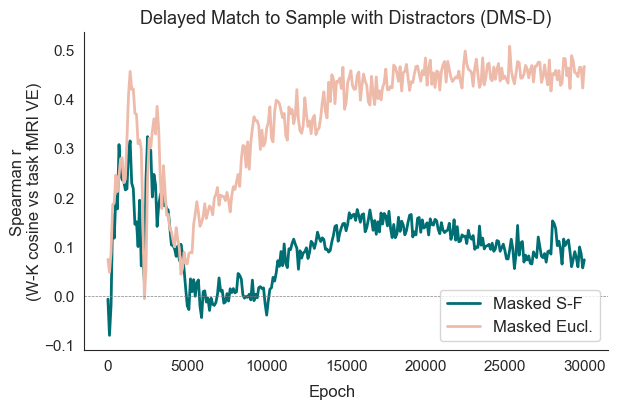

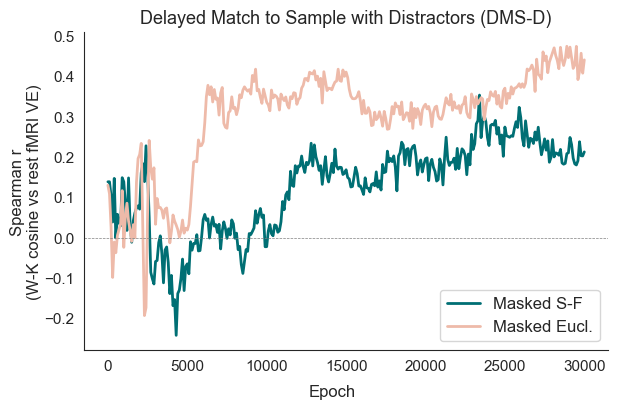

In [93]:
# At each epoch, correlate weight-kernel similarity (cosine) with fMRI VE across
# runs within each kernel type. Plot the Spearman r trajectory over training.

wk_metric = 'cosine'

fmri_ve_corr_metrics = [
    {
        'key': 'fmri_task_ve',
        'baseline': fmri_baselines['task'],
        'ylabel': f'Spearman r\n(W-K {wk_metric} vs task fMRI VE)',
        'file_suff': f'corr_wk_{wk_metric}_vs_fmri_task_ve',
    },
    {
        'key': 'fmri_rest_ve',
        'baseline': fmri_baselines['rest'],
        'ylabel': f'Spearman r\n(W-K {wk_metric} vs rest fMRI VE)',
        'file_suff': f'corr_wk_{wk_metric}_vs_fmri_rest_ve',
    },
]

for vm in fmri_ve_corr_metrics:
    if vm['baseline'] is None:
        print(f'Skipping {vm["key"]} (no fMRI data)')
        continue

    size_scale = 2.0
    font_size = int(6 * size_scale)
    set_font_size(font_size)
    fig, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                           squeeze=True, sharex=True, sharey=True)

    for model_idx in range(n_models):
        res = results[model_idx]
        if res is None:
            continue

        this = model_params.iloc[model_idx]
        task_index = this.task_index
        kernel_index = this.kernel_index
        ax = fig.axes[task_index]

        # skip models without spatial kernel
        ep0 = res['sampled_epochs'][0]
        if res['runs'][0]['epochs'][ep0]['weight_kernel_similarity'] is None:
            continue

        epochs = np.array(res['sampled_epochs'])
        n_runs = res['n_runs']

        # extract per-run arrays: (n_runs, n_epochs)
        wk_vals = np.zeros((n_runs, len(epochs)))
        ve_vals = np.full((n_runs, len(epochs)), np.nan)

        for ri, run in enumerate(res['runs']):
            for ei, ep in enumerate(epochs):
                ep_data = run['epochs'][ep]
                wk_vals[ri, ei] = ep_data['weight_kernel_similarity'][wk_metric]
                ve_arr = ep_data[vm['key']]
                if ve_arr is not None:
                    ve_vals[ri, ei] = ve_arr.sum(axis=0).mean() / vm['baseline']

        # at each epoch, correlate across runs
        corr_per_epoch = np.full(len(epochs), np.nan)
        for ei in range(len(epochs)):
            wk_col = wk_vals[:, ei]
            ve_col = ve_vals[:, ei]
            valid = ~np.isnan(wk_col) & ~np.isnan(ve_col)
            if valid.sum() > 3:
                r, _ = stats.spearmanr(wk_col[valid], ve_col[valid])
                corr_per_epoch[ei] = r

        ax.plot(epochs, corr_per_epoch, color=color_palette[kernel_index],
                label=this.kernel_label, linewidth=2)
        ax.set_title(this.task_label)

    # reference line at r=0
    for ax in fig.axes[:n_tasks]:
        ax.axhline(y=0, color=[0.5]*3, linestyle='--', linewidth=0.5)

    handles, labels = fig.axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.axes[0].legend(by_label.values(), by_label.keys(), loc='lower right')

    fig.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    fig.text(0.0, 0.5, vm['ylabel'], ha='center', va='center', rotation='vertical')
    sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    fig.tight_layout()

    if save_figs:
        fig.savefig(os.path.join(outdir, f'trajectory_{vm["file_suff"]}.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()

# Combined panel: accuracy, similarity, fMRI VE

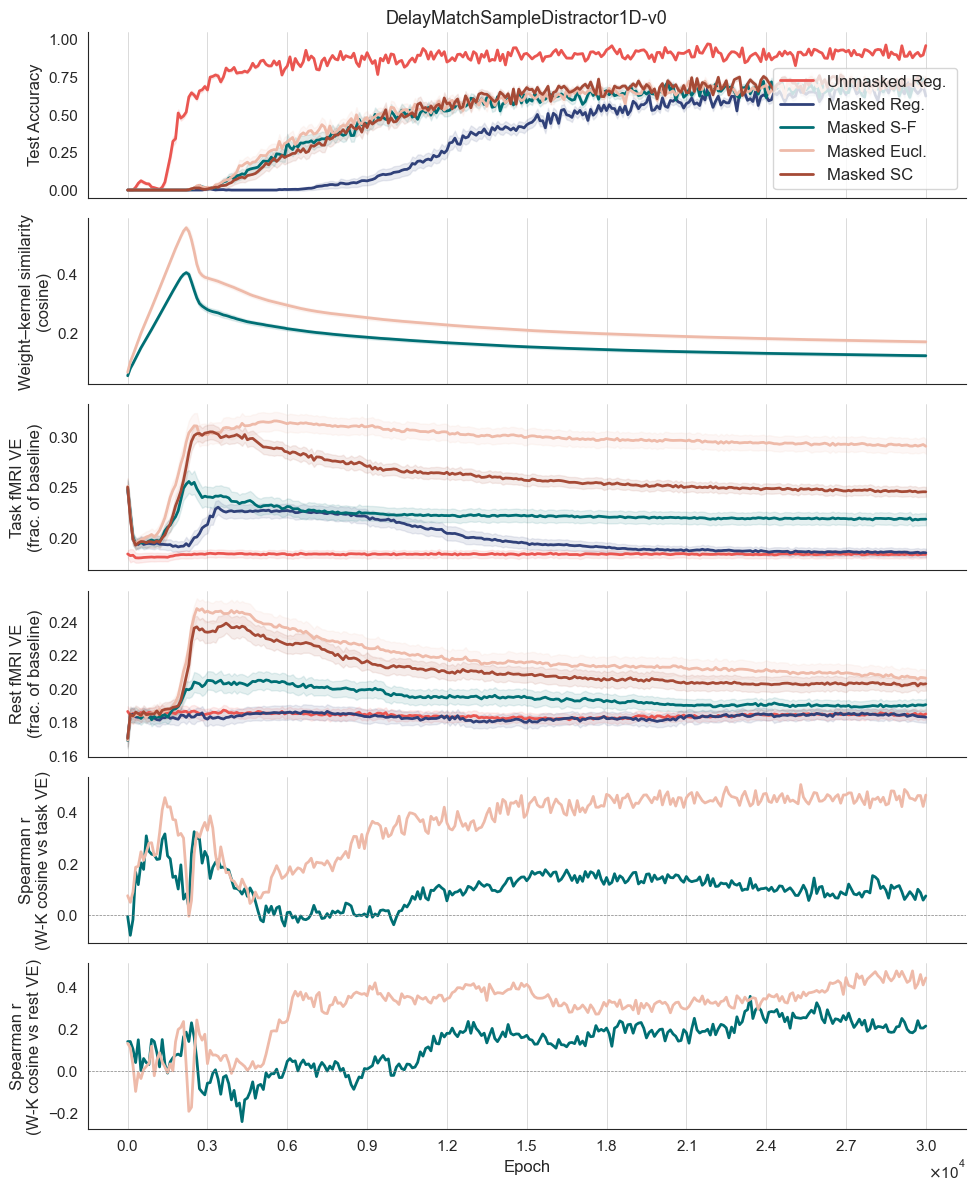

In [94]:
# Combined panel: accuracy, similarity, task fMRI VE, rest fMRI VE,
# corr(W-K cosine vs task VE), corr(W-K cosine vs rest VE)
# Columns = tasks, rows = metrics

has_fmri = fmri_baselines['task'] is not None
wk_metric_mean = 'cosine'   # for the mean trajectory row
wk_metric_corr = 'cosine'     # for the across-run correlation rows

# define rows
row_defs = [
    {'type': 'mean',  'key': 'accuracy',              'label': 'Test Accuracy'},
    {'type': 'mean',  'key': f'wk_{wk_metric_mean}',  'label': f'Weight–kernel similarity\n({wk_metric_mean})'},
]
if has_fmri:
    row_defs += [
        {'type': 'mean',  'key': 'fmri_task_ve',  'label': 'Task fMRI VE\n(frac. of baseline)'},
        {'type': 'mean',  'key': 'fmri_rest_ve',  'label': 'Rest fMRI VE\n(frac. of baseline)'},
        {'type': 'corr',  'key': 'fmri_task_ve',  'label': f'Spearman r\n(W-K {wk_metric_corr} vs task VE)'},
        {'type': 'corr',  'key': 'fmri_rest_ve',  'label': f'Spearman r\n(W-K {wk_metric_corr} vs rest VE)'},
    ]

n_metric_rows = len(row_defs)

size_scale = 2.0
font_size = int(6 * size_scale)
set_font_size(font_size)
fig_w = 5 * n_fig_columns * size_scale
fig_h = 1 * n_metric_rows * size_scale

fig, axes = plt.subplots(n_metric_rows, n_fig_columns,
                          figsize=(fig_w, fig_h),
                          squeeze=False, sharex=True, sharey='row')

# --- Pre-extract all per-run data ---
# Store {model_idx: {metric: array(n_runs, n_epochs)}}
model_data = {}
for model_idx in range(n_models):
    res = results[model_idx]
    if res is None:
        continue
    this = model_params.iloc[model_idx]
    epochs = np.array(res['sampled_epochs'])
    n_runs = res['n_runs']
    has_wk = res['runs'][0]['epochs'][epochs[0]]['weight_kernel_similarity'] is not None

    d = {'epochs': epochs, 'n_runs': n_runs, 'has_wk': has_wk}
    d['accuracy'] = np.zeros((n_runs, len(epochs)))
    d[f'wk_{wk_metric_mean}'] = np.full((n_runs, len(epochs)), np.nan)
    d[f'wk_{wk_metric_corr}'] = np.full((n_runs, len(epochs)), np.nan)
    d['fmri_task_ve'] = np.full((n_runs, len(epochs)), np.nan)
    d['fmri_rest_ve'] = np.full((n_runs, len(epochs)), np.nan)

    for ri, run in enumerate(res['runs']):
        for ei, ep in enumerate(epochs):
            ep_data = run['epochs'][ep]
            d['accuracy'][ri, ei] = ep_data['accuracy']
            if has_wk:
                d[f'wk_{wk_metric_mean}'][ri, ei] = ep_data['weight_kernel_similarity'][wk_metric_mean]
                d[f'wk_{wk_metric_corr}'][ri, ei] = ep_data['weight_kernel_similarity'][wk_metric_corr]
            if has_fmri:
                ve_task = ep_data.get('fmri_task_ve')
                ve_rest = ep_data.get('fmri_rest_ve')
                if ve_task is not None:
                    d['fmri_task_ve'][ri, ei] = ve_task.sum(axis=0).mean() / fmri_baselines['task']
                if ve_rest is not None:
                    d['fmri_rest_ve'][ri, ei] = ve_rest.sum(axis=0).mean() / fmri_baselines['rest']

    model_data[model_idx] = d

# --- Plot each row ---
for row_idx, rdef in enumerate(row_defs):

    if rdef['type'] == 'mean':
        # line + CI of the metric mean across runs
        for model_idx in range(n_models):
            if model_idx not in model_data:
                continue
            d = model_data[model_idx]
            this = model_params.iloc[model_idx]
            ax = axes[row_idx, this.task_index]
            vals = d[rdef['key']]
            if np.all(np.isnan(vals)):
                continue
            m = np.nanmean(vals, axis=0)
            se = np.nanstd(vals, axis=0) / np.sqrt(d['n_runs'])
            ax.plot(d['epochs'], m, color=color_palette[this.kernel_index],
                    label=this.kernel_label, linewidth=2)
            ax.fill_between(d['epochs'], m - 1.96 * se, m + 1.96 * se,
                             color=color_palette[this.kernel_index], alpha=0.1)

    elif rdef['type'] == 'corr':
        # per-epoch Spearman r between W-K cosine and fMRI VE across runs
        for model_idx in range(n_models):
            if model_idx not in model_data:
                continue
            d = model_data[model_idx]
            this = model_params.iloc[model_idx]
            if not d['has_wk']:
                continue
            ax = axes[row_idx, this.task_index]
            epochs = d['epochs']
            wk = d[f'wk_{wk_metric_corr}']
            ve = d[rdef['key']]

            corr_per_epoch = np.full(len(epochs), np.nan)
            for ei in range(len(epochs)):
                valid = ~np.isnan(wk[:, ei]) & ~np.isnan(ve[:, ei])
                if valid.sum() > 3:
                    r, _ = stats.spearmanr(wk[valid, ei], ve[valid, ei])
                    corr_per_epoch[ei] = r

            ax.plot(epochs, corr_per_epoch, color=color_palette[this.kernel_index],
                    label=this.kernel_label, linewidth=2)

        # reference line at r=0
        for col in range(n_fig_columns):
            axes[row_idx, col].axhline(y=0, color=[0.5]*3, linestyle='--', linewidth=0.5)

# --- Formatting ---
for col in range(n_fig_columns):
    if col < n_tasks:
        axes[0, col].set_title(task_names[col])
    axes[-1, col].set_xlabel('Epoch')

for row_idx, rdef in enumerate(row_defs):
    axes[row_idx, 0].set_ylabel(rdef['label'])

axes[0, 0].set_ylim((-0.05, 1.05))

handles, labels = axes[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0, 0].legend(by_label.values(), by_label.keys(), loc='lower right')

for row_idx in range(n_metric_rows):
    for col in range(n_fig_columns):
        ax = axes[row_idx, col]
        xl = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 11)
        xl = np.linspace(epochs[0], epochs[-1], 11)
        ax.set_xticks(xl)
        ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.5)

sns.despine(fig=fig, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
fig.tight_layout()

plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
plt.minorticks_on()

if save_figs:
    fig.savefig(os.path.join(outdir, 'trajectory_combined_panel.svg'),
                dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

# Joint trajectory: weight-kernel similarity vs fMRI VE

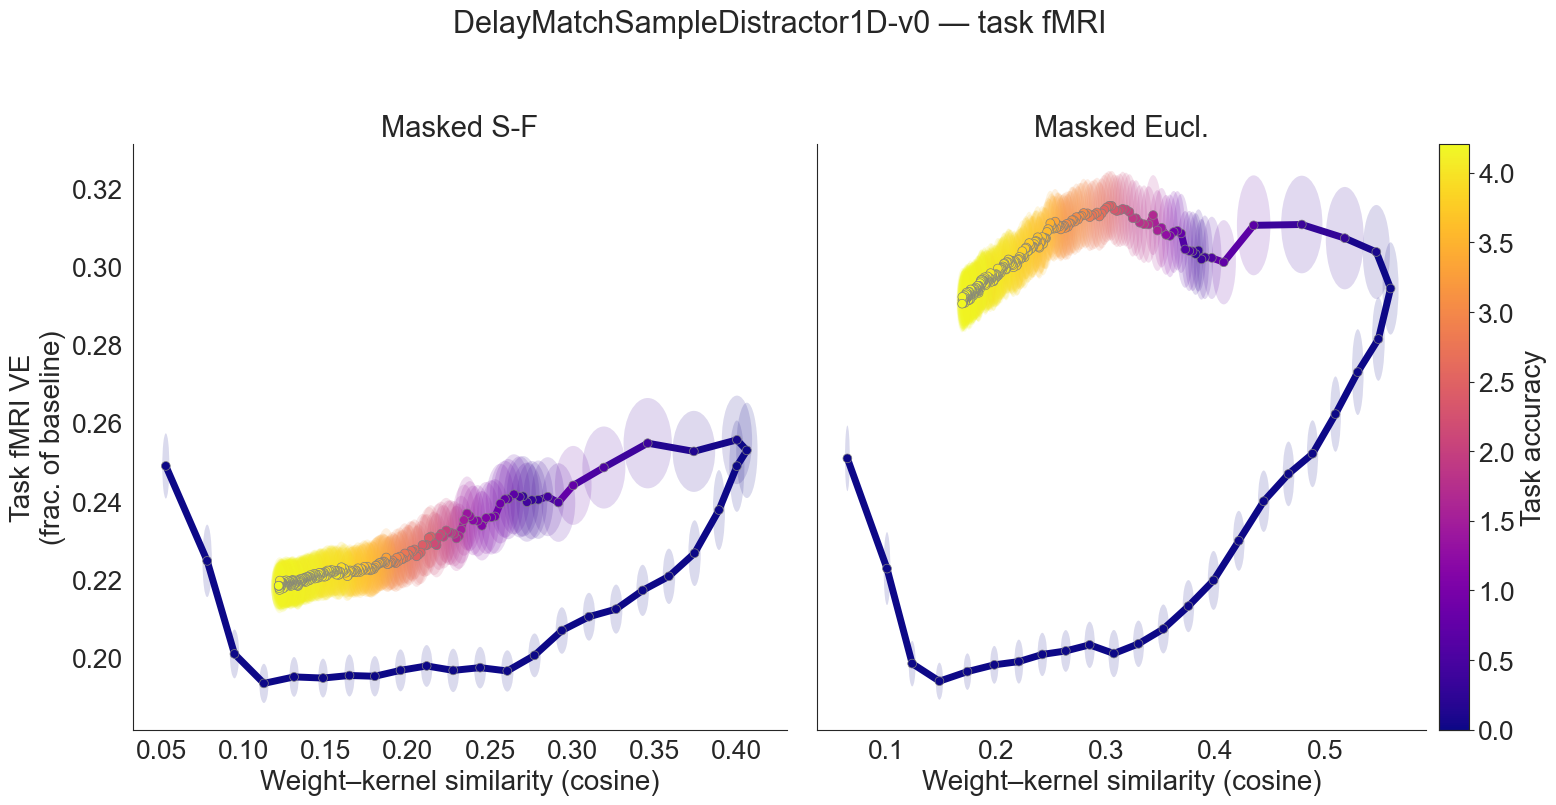

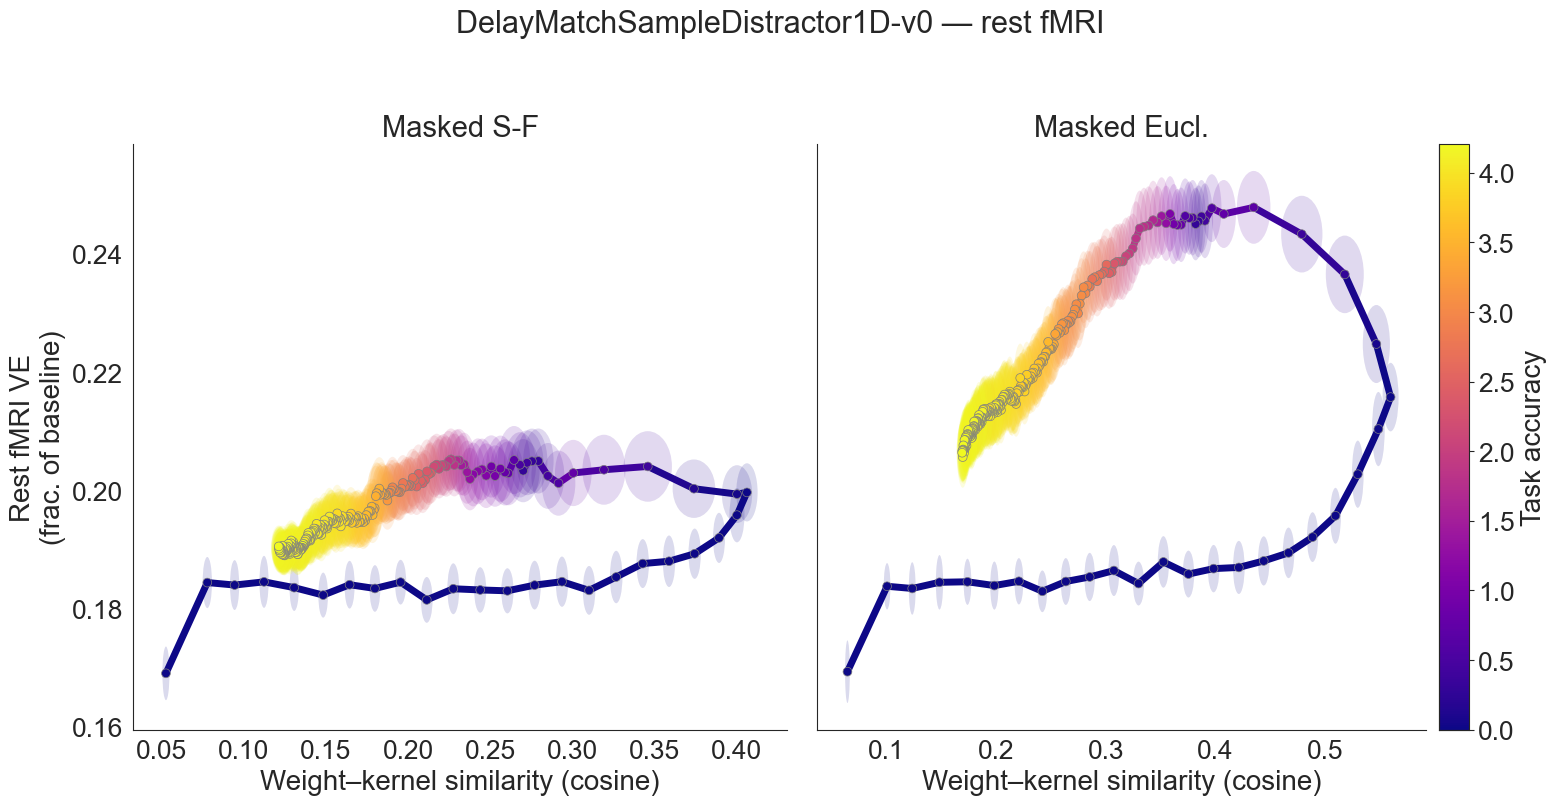

In [95]:
# Scatter: weight-kernel similarity (x) vs fMRI VE (y), color-coded by epoch
# One subplot per (task x kernel), only for models with spatial kernels
# Mean trajectory (thick line) + 95% CI ellipses, individual runs at alpha 0.1

if True:
    
    log_acc = True
    show_runs = False

    if fmri_baselines['task'] is None:
        print('Skipping (no fMRI data)')
    else:
        wk_metric = 'cosine'

        fmri_configs = [
            {'key': 'fmri_task_ve', 'baseline': fmri_baselines['task'],
             'ylabel': 'Task fMRI VE\n(frac. of baseline)', 'suffix': 'task'},
            {'key': 'fmri_rest_ve', 'baseline': fmri_baselines['rest'],
             'ylabel': 'Rest fMRI VE\n(frac. of baseline)', 'suffix': 'rest'},
        ]

        size_scale = 2.0
        font_size = int(10 * size_scale)
        set_font_size(font_size)

        for fc in fmri_configs:
            fmri_key = fc['key']
            fmri_baseline = fc['baseline']

            for task_idx in range(n_tasks):
                # collect models for this task that have spatial kernels
                task_models = []
                for model_idx in range(n_models):
                    res = results[model_idx]
                    if res is None:
                        continue
                    this = model_params.iloc[model_idx]
                    if this.task_index != task_idx:
                        continue
                    ep0 = res['sampled_epochs'][0]
                    if res['runs'][0]['epochs'][ep0]['weight_kernel_similarity'] is None:
                        continue
                    task_models.append((model_idx, this))

                if not task_models:
                    continue

                n_panels = len(task_models)
                fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels * size_scale, 4 * size_scale),
                                        squeeze=False, sharey=True)
                axes = axes.ravel()

                for pi, (model_idx, this) in enumerate(task_models):
                    res = results[model_idx]
                    ax = axes[pi]
                    epochs = np.array(res['sampled_epochs'])
                    n_runs = res['n_runs']

                    # colormap: epoch progression
                    if 'GoNogo' in task_names[task_idx]:
                        cmbounds = [0.4, 1]
                    else:
                        cmbounds = [0, 0.66]
                    cmbounds = np.array(cmbounds)
                    if log_acc:
                        cmbounds = np.log1p(cmbounds*100)
                    cmap = cm.plasma
                    norm = plt.Normalize(cmbounds[0], cmbounds[1])

                    # collect all runs into arrays: (n_runs, n_epochs)
                    all_wk = np.full((n_runs, len(epochs)), np.nan)
                    all_ve = np.full((n_runs, len(epochs)), np.nan)
                    all_ac = np.full((n_runs, len(epochs)), np.nan)

                    for ri, run in enumerate(res['runs']):
                        for ei, ep in enumerate(epochs):
                            ep_data = run['epochs'][ep]
                            all_ac[ri, ei] = ep_data['accuracy']
                            all_wk[ri, ei] = ep_data['weight_kernel_similarity'][wk_metric]
                            ve_arr = ep_data[fmri_key]
                            if ve_arr is not None:
                                all_ve[ri, ei] = ve_arr.sum(axis=0).mean() / fmri_baseline
                    if log_acc:
                        all_ac = np.log1p(all_ac*100)

                    # individual run traces at low alpha
                    if show_runs:
                        for ri in range(0, n_runs, 4):
                            for ei in range(len(epochs) - 1):
                                ax.plot(all_wk[ri, ei:ei+2], all_ve[ri, ei:ei+2],
                                        color=cmap(norm(all_ac[ri,ei])), linewidth=0.5, alpha=0.2)
                            ax.scatter(all_wk[ri], all_ve[ri], c=all_ac[ri,:], cmap=cmap, norm=norm,
                                    s=10, alpha=0.01, edgecolors='none', zorder=2)
                    
                    # mean trajectory (thick line) with CI ellipses
                    wk_mean = np.nanmean(all_wk, axis=0)
                    ve_mean = np.nanmean(all_ve, axis=0)
                    ac_mean = np.nanmean(all_ac, axis=0)
                    wk_se = np.nanstd(all_wk, axis=0) / np.sqrt(n_runs)
                    ve_se = np.nanstd(all_ve, axis=0) / np.sqrt(n_runs)
                    ac_se = np.nanstd(all_ac, axis=0) / np.sqrt(n_runs)
                    
                    # plot mean trajectory colored by accuracy
                    for ei in range(len(epochs) - 1):
                        ax.plot(wk_mean[ei:ei+2], ve_mean[ei:ei+2],
                                color=cmap(norm(ac_mean[ei])), linewidth=5, alpha=1.0, zorder=4)
                    ax.scatter(wk_mean, ve_mean, c=ac_mean, cmap=cmap, norm=norm,
                              s=40, alpha=1.0, edgecolors='grey', linewidths=0.5, zorder=5)
                    
                    # CI ellipses at each epoch (horizontal = wk CI, vertical = ve CI), accuracy color
                    for ei in range(len(epochs)):
                        ellipse = plt.matplotlib.patches.Ellipse(
                            (wk_mean[ei], ve_mean[ei]),
                            width=2 * 1.96 * wk_se[ei],
                            height=2 * 1.96 * ve_se[ei],
                            facecolor=cmap(norm(ac_mean[ei])),
                            alpha=0.15,
                            edgecolor='none',
                            zorder=3,
                        )
                        ax.add_patch(ellipse)

                    ax.set_xlabel(f'Weight\u2013kernel similarity ({wk_metric})')
                    if pi == 0:
                        ax.set_ylabel(fc['ylabel'])
                    ax.set_title(this.kernel_label)

                # colorbar on last axis
                sm = cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                cbar = fig.colorbar(sm, ax=axes[-1], fraction=0.05, pad=0.02)
                cbar.set_label('Task accuracy')

                fig.suptitle(f'{task_names[task_idx]} — {fc["suffix"]} fMRI', y=1.02)
                sns.despine(fig=fig, offset=0, trim=False)
                fig.tight_layout()

                if save_figs:
                    fig.savefig(os.path.join(outdir, f'trajectory_joint_{fc["suffix"]}_{task_names[task_idx]}.svg'),
                                dpi=300, bbox_inches='tight', pad_inches=0.01)
                plt.show()

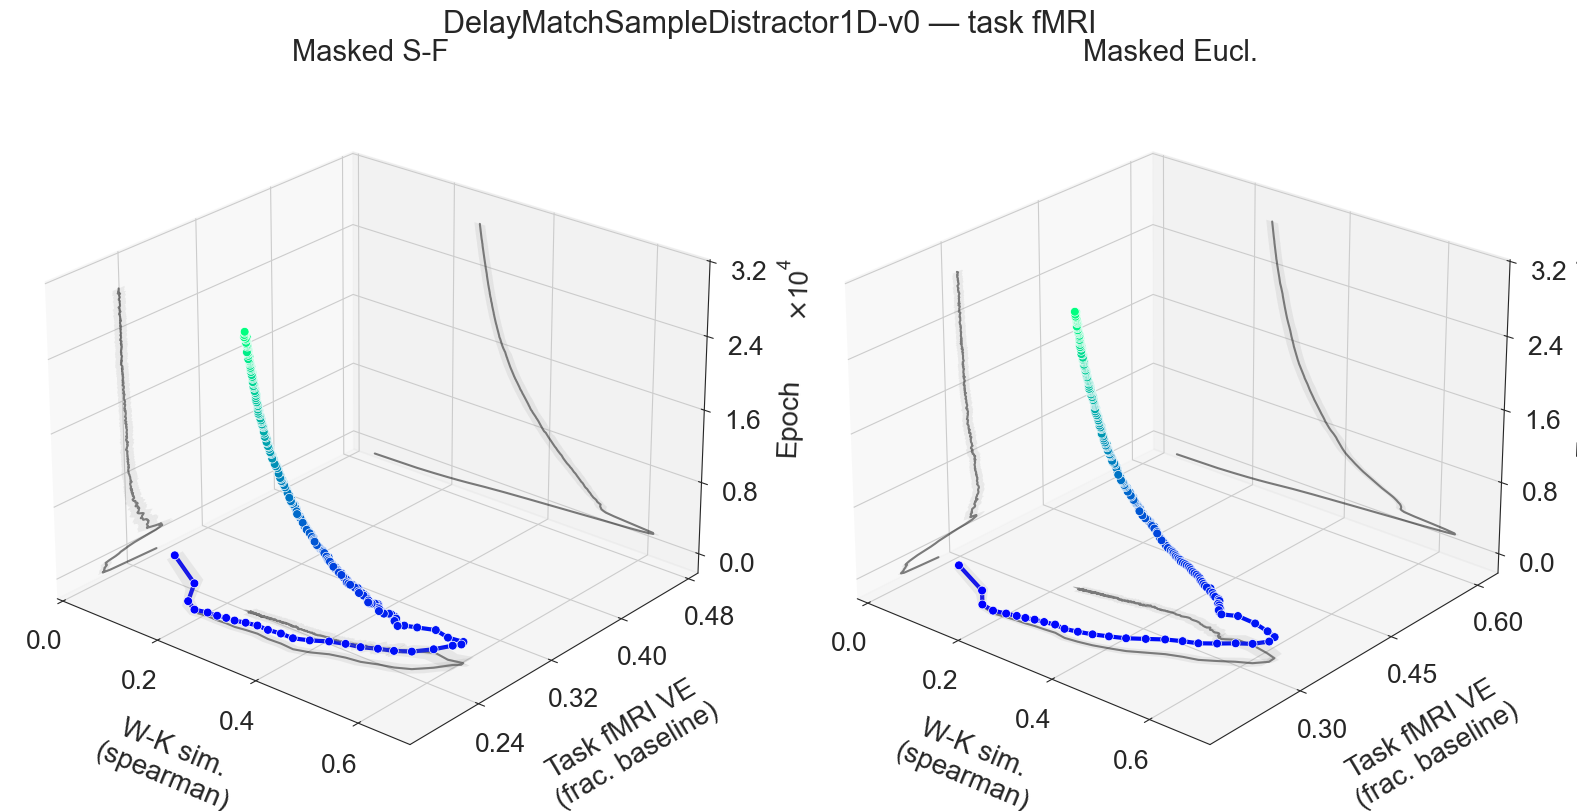

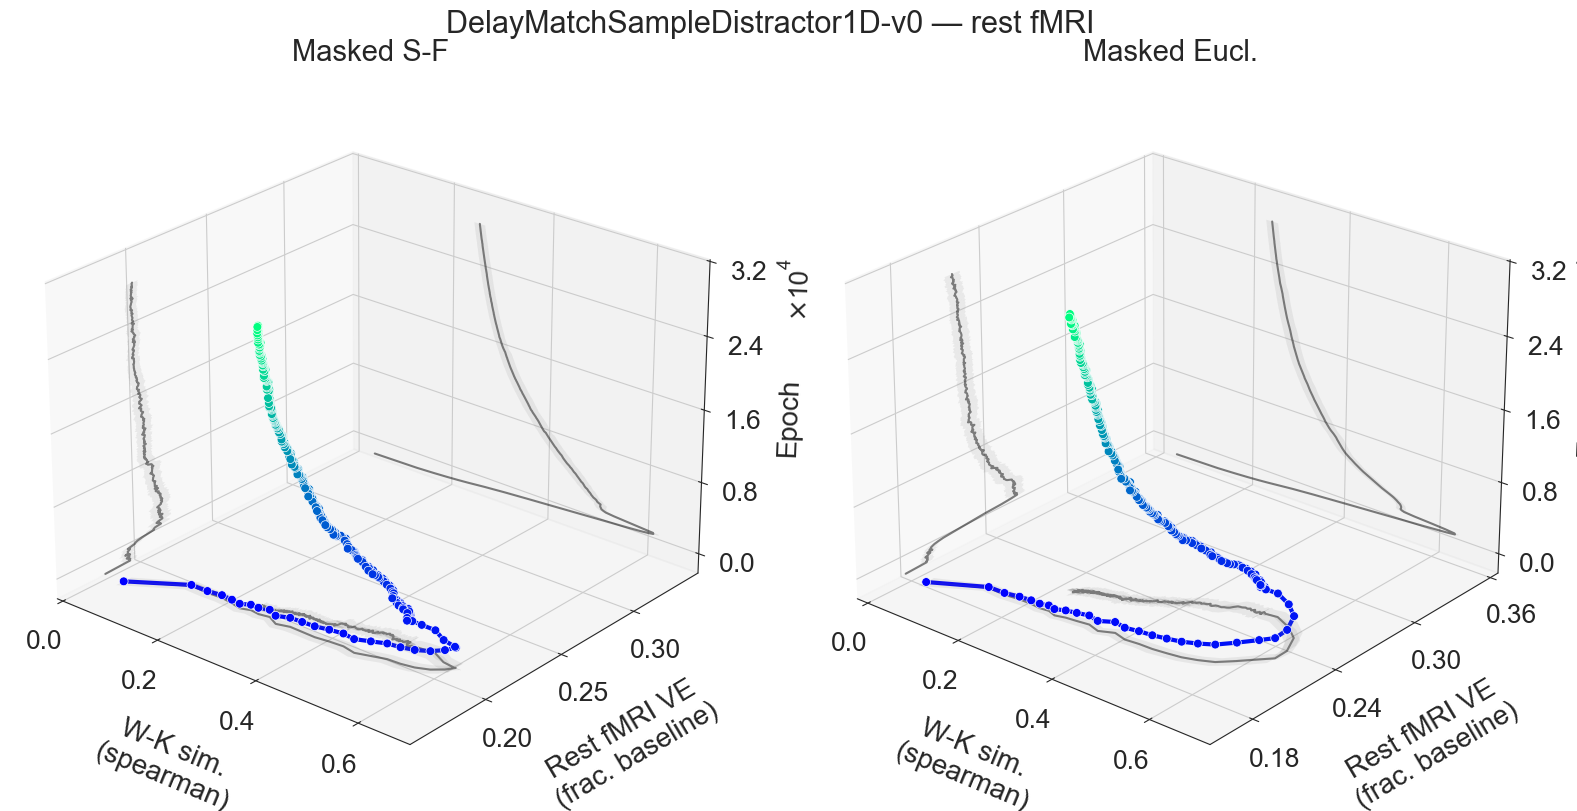

In [96]:
# 3D joint trajectory: weight-kernel similarity (x) vs fMRI VE (y) vs epoch (z)
# Mean trajectory in 3D (viridis), with 2D projections (black) + CIs on each wall

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.ticker import ScalarFormatter

if True:

    if fmri_baselines['task'] is None:
        print('Skipping (no fMRI data)')
    else:
        wk_metric = 'spearman'

        fmri_configs = [
            {'key': 'fmri_task_ve', 'baseline': fmri_baselines['task'],
             'ylabel': 'Task fMRI VE\n(frac. baseline)', 'suffix': 'task'},
            {'key': 'fmri_rest_ve', 'baseline': fmri_baselines['rest'],
             'ylabel': 'Rest fMRI VE\n(frac. baseline)', 'suffix': 'rest'},
        ]

        size_scale = 2.0
        font_size = int(10 * size_scale)
        set_font_size(font_size)

        proj_color = 'black'
        proj_ci_color = [0.5, 0.5, 0.5]  # grey for CI fills
        proj_alpha = 0.12  # fill alpha for CI bands
        proj_line_alpha = 0.5  # line alpha for projection mean lines

        for fc in fmri_configs:
            fmri_key = fc['key']
            fmri_baseline = fc['baseline']

            for task_idx in range(n_tasks):
                # collect models for this task that have spatial kernels
                task_models = []
                for model_idx in range(n_models):
                    res = results[model_idx]
                    if res is None:
                        continue
                    this = model_params.iloc[model_idx]
                    if this.task_index != task_idx:
                        continue
                    ep0 = res['sampled_epochs'][0]
                    if res['runs'][0]['epochs'][ep0]['weight_kernel_similarity'] is None:
                        continue
                    task_models.append((model_idx, this))

                if not task_models:
                    continue

                n_panels = len(task_models)
                fig = plt.figure(figsize=(4 * n_panels * size_scale, 4.5 * size_scale))

                # manually place each 3D subplot for tight packing + vertical centering
                panel_width = 1.0 / n_panels
                v_margin = 0.10  # symmetric top/bottom margin for vertical centering
                h_pad = 0.     # horizontal padding on left/right edges for labels
                for pi, (model_idx, this) in enumerate(task_models):
                    res = results[model_idx]
                    # position: [left, bottom, width, height] in figure-fraction
                    ax_left = h_pad + pi * (1.0 - 2 * h_pad) / n_panels
                    ax_width = (1.0 - 2 * h_pad) / n_panels
                    ax = fig.add_axes([ax_left, v_margin, ax_width, 1.0 - 2 * v_margin],
                                      projection='3d')
                    epochs = np.array(res['sampled_epochs'])
                    n_runs = res['n_runs']

                    # colormap: epoch progression
                    cmap = cm.winter
                    norm = plt.Normalize(epochs.min(), epochs.max())

                    # collect all runs into arrays: (n_runs, n_epochs)
                    all_wk = np.full((n_runs, len(epochs)), np.nan)
                    all_ve = np.full((n_runs, len(epochs)), np.nan)

                    for ri, run in enumerate(res['runs']):
                        for ei, ep in enumerate(epochs):
                            ep_data = run['epochs'][ep]
                            all_wk[ri, ei] = ep_data['weight_kernel_similarity'][wk_metric]
                            ve_arr = ep_data[fmri_key]
                            if ve_arr is not None:
                                all_ve[ri, ei] = ve_arr.sum(axis=0).mean() / fmri_baseline

                    # --- compute mean and SE ---
                    wk_mean = np.nanmean(all_wk, axis=0)
                    ve_mean = np.nanmean(all_ve, axis=0)
                    wk_se = np.nanstd(all_wk, axis=0) / np.sqrt(n_runs)
                    ve_se = np.nanstd(all_ve, axis=0) / np.sqrt(n_runs)

                    wk_lo = wk_mean - 1.96 * wk_se
                    wk_hi = wk_mean + 1.96 * wk_se
                    ve_lo = ve_mean - 1.96 * ve_se
                    ve_hi = ve_mean + 1.96 * ve_se

                    # get axis limits for wall placement (computed after data range)
                    wk_min = np.nanmin(all_wk) - 0.02 * (np.nanmax(all_wk) - np.nanmin(all_wk))
                    ve_max = np.nanmax(all_ve) + 0.05 * (np.nanmax(all_ve) - np.nanmin(all_ve))
                    ep_min = epochs.min()

                    # --- 3D mean trajectory (clean, no CIs) ---
                    for ei in range(len(epochs) - 1):
                        ax.plot(wk_mean[ei:ei+2], ve_mean[ei:ei+2], epochs[ei:ei+2],
                                color=cmap(norm(epochs[ei])), linewidth=3, zorder=4)
                    ax.scatter(wk_mean, ve_mean, epochs, c=epochs, cmap=cmap, norm=norm,
                              s=40, edgecolors='white', linewidths=0.5, zorder=5, depthshade=False)

                    # --- Projection 1: XY floor (wk vs ve at z=ep_min) ---
                    ax.plot(wk_mean, ve_mean, zs=ep_min, zdir='z',
                            color=proj_color, linewidth=1.5, alpha=proj_line_alpha, zorder=1)
                    for ei in range(len(epochs) - 1):
                        verts_wk = [
                            [wk_lo[ei], ve_mean[ei], ep_min],
                            [wk_hi[ei], ve_mean[ei], ep_min],
                            [wk_hi[ei+1], ve_mean[ei+1], ep_min],
                            [wk_lo[ei+1], ve_mean[ei+1], ep_min],
                        ]
                        ax.add_collection3d(Poly3DCollection([verts_wk], color=proj_ci_color, alpha=proj_alpha, edgecolor='none', zorder=0))
                        verts_ve = [
                            [wk_mean[ei], ve_lo[ei], ep_min],
                            [wk_mean[ei], ve_hi[ei], ep_min],
                            [wk_mean[ei+1], ve_hi[ei+1], ep_min],
                            [wk_mean[ei+1], ve_lo[ei+1], ep_min],
                        ]
                        ax.add_collection3d(Poly3DCollection([verts_ve], color=proj_ci_color, alpha=proj_alpha, edgecolor='none', zorder=0))

                    # --- Projection 2: XZ wall (wk vs epoch at y=ve_max) ---
                    ax.plot(wk_mean, [ve_max]*len(epochs), epochs,
                            color=proj_color, linewidth=1.5, alpha=proj_line_alpha, zorder=1)
                    for ei in range(len(epochs) - 1):
                        verts = [
                            [wk_lo[ei], ve_max, epochs[ei]],
                            [wk_hi[ei], ve_max, epochs[ei]],
                            [wk_hi[ei+1], ve_max, epochs[ei+1]],
                            [wk_lo[ei+1], ve_max, epochs[ei+1]],
                        ]
                        ax.add_collection3d(Poly3DCollection([verts], color=proj_ci_color, alpha=proj_alpha, edgecolor='none', zorder=0))

                    # --- Projection 3: YZ wall (ve vs epoch at x=wk_min) ---
                    ax.plot([wk_min]*len(epochs), ve_mean, epochs,
                            color=proj_color, linewidth=1.5, alpha=proj_line_alpha, zorder=1)
                    for ei in range(len(epochs) - 1):
                        verts = [
                            [wk_min, ve_lo[ei], epochs[ei]],
                            [wk_min, ve_hi[ei], epochs[ei]],
                            [wk_min, ve_hi[ei+1], epochs[ei+1]],
                            [wk_min, ve_lo[ei+1], epochs[ei+1]],
                        ]
                        ax.add_collection3d(Poly3DCollection([verts], color=proj_ci_color, alpha=proj_alpha, edgecolor='none', zorder=0))

                    ax.set_xlabel(f'W-K sim.\n({wk_metric})', labelpad=30)
                    ax.set_ylabel(fc['ylabel'], labelpad=30)
                    ax.set_zlabel('Epoch', labelpad=15)
                    ax.set_title(this.kernel_label, pad=15)
                    ax.view_init(elev=25, azim=-50)

                    # reduce tick density and add padding so ticks don't overlap labels
                    ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=4))
                    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))
                    ax.zaxis.set_major_locator(plt.MaxNLocator(nbins=5))
                    ax.tick_params(axis='x', pad=8)
                    ax.tick_params(axis='y', pad=8)
                    ax.tick_params(axis='z', pad=8)

                    # scientific notation on z-axis (plt.ticklabel_format doesn't work for 3D)
                    z_fmt = ScalarFormatter(useMathText=True)
                    z_fmt.set_powerlimits((0, 0))
                    ax.zaxis.set_major_formatter(z_fmt)

                fig.suptitle(f'{task_names[task_idx]} — {fc["suffix"]} fMRI', y=0.98)

                if save_figs:
                    fig.savefig(os.path.join(outdir, f'trajectory_joint_3d_{fc["suffix"]}_{task_names[task_idx]}.svg'),
                                dpi=300, bbox_inches='tight', pad_inches=0.05)
                plt.show()